In [26]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LinearRegression


In [2]:
df = pd.read_csv('Social_Network_Ads.csv')

In [5]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [7]:
df.isna().sum()

User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


In [10]:
df['Gender'].unique()

array(['Male', 'Female'], dtype=object)

In [12]:
df['Purchased'].unique()

array([0, 1])

In [16]:
df = df.drop('User ID',axis=1)

In [17]:
df.head()

,Gender,Age,EstimatedSalary,Purchased
0,Male,19,19000,0
1,Male,35,20000,0
2,Female,26,43000,0
3,Female,27,57000,0
4,Male,19,76000,0


In [18]:
df = pd.get_dummies(df,drop_first=True)

In [19]:
df

,Age,EstimatedSalary,Purchased,Gender_Male
0,19,19000,0,True
1,35,20000,0,True
2,26,43000,0,False
3,27,57000,0,False
4,19,76000,0,True
...,...,...,...,...
395,46,41000,1,False
396,51,23000,1,True
397,50,20000,1,False
398,36,33000,0,True


In [20]:
y = df[['Purchased']]
x = df.drop('Purchased',axis=1)

In [22]:
x.head()

,Age,EstimatedSalary,Gender_Male
0,19,19000,True
1,35,20000,True
2,26,43000,False
3,27,57000,False
4,19,76000,True


In [23]:
y.head()

,Purchased
0,0
1,0
2,0
3,0
4,0


In [25]:
# test-size - 20%
# random_state = 70
x_train,x_test,y_train,y_test = train_test_split(x,y,train_size=0.8,random_state=70)

# KNN

In [34]:
KNN  = KNeighborsClassifier(n_neighbors=3)
KNN.fit(x_train,y_train)
y_pred  = KNN.predict(x_test)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


In [35]:
y_pred

array([1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0])

In [40]:
prediction = pd.DataFrame({
    'actul' : y_test.squeeze(),
    'Pridicted' : y_pred.squeeze()
})
prediction

,actul,Pridicted
283,1,1
74,0,0
292,1,1
150,0,0
311,1,1
...,...,...
112,0,0
38,0,0
302,1,1
65,0,0


In [49]:
# age :25 
# salary:30000
# gender : False
y_pred_data  = KNN.predict([[25,30000,False]])
y_pred_data

if y_pred_data == 1:
    print('Purchased')
else:
    print('Not Purchased')
    

Purchased


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


In [50]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [53]:
conf_matrix = confusion_matrix(y_test,y_pred)
conf_matrix


array([[45, 11],
       [ 3, 21]])

<Axes: >

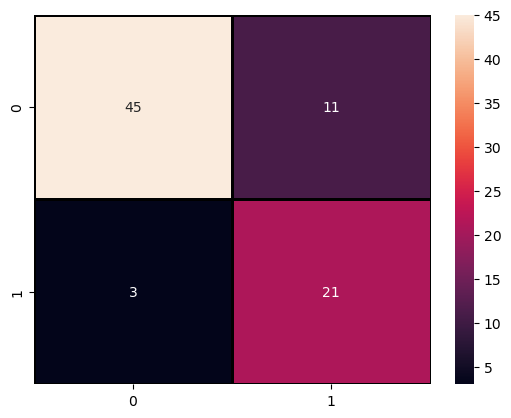

In [58]:
sns.heatmap(conf_matrix,annot=True,
            linecolor='black',
            linewidths=2,
           x)